# Monthly forecasting of equivalent new maternity leaves in a hospital

## Notebook 03 — Baselines and Model Comparison

This notebook compares the best **multiple linear regression** model obtained in Notebook 2 against several simple baseline models.

In this case, with the updated fictitious dataframe, the best model found in Notebook 2 is:

```text
statsmodels_ols
```

The central question is:

> Does the multiple linear regression model provide real predictive value compared with simple prediction rules?

Baselines are important because a model is only worth using if it improves upon simple, interpretable, and easy-to-implement references.

## Imports

In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

sns.set_style('whitegrid')

## Dataset loading

The clean dataset generated in Notebook 1 is loaded:

```text
data/df_model_full.csv
```

This dataset contains the target variable and the candidate variables already prepared for modeling.

In [2]:
df = pd.read_csv('../data/df_model_full.csv')

df['MES'] = pd.to_datetime(df['MES'])
df = df.sort_values('MES').reset_index(drop=True)

df.head()

,MES,mat_eq_nuevas_mes,ppef_mujeres_25_40,pct_indef_25_40,pct_amb_fill_25_40,RE_ponderado_lag1,RE_ponderado_lag2,RE_ponderado_lag3,mat_eq_lag1,mat_eq_lag12,mes
0,2016-01-31,3.5400,969.6898,0.1601,0.1505,0.0000,0.0000,0.0000,0.0000,0.0000,1
1,2016-02-29,6.0628,"1,019.6952",0.1480,0.1099,15.6240,0.0000,0.0000,3.5400,0.0000,2
2,2016-03-31,5.5194,"1,033.5400",0.1455,0.1173,16.7160,15.6240,0.0000,6.0628,0.0000,3
3,2016-04-30,2.7350,"1,036.7885",0.1419,0.1133,16.4640,16.7160,15.6240,5.5194,0.0000,4
4,2016-05-31,7.0039,"1,022.9498",0.1401,0.1218,11.2560,16.4640,16.7160,2.7350,0.0000,5


In [3]:
print('Time range:', df['MES'].min(), '->', df['MES'].max())
print('Number of observations:', len(df))
df.info()

Time range: 2016-01-31 00:00:00 -> 2026-03-31 00:00:00
Number of observations: 123
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   MES                 123 non-null    datetime64[ns]
 1   mat_eq_nuevas_mes   123 non-null    float64       
 2   ppef_mujeres_25_40  123 non-null    float64       
 3   pct_indef_25_40     123 non-null    float64       
 4   pct_amb_fill_25_40  123 non-null    float64       
 5   RE_ponderado_lag1   123 non-null    float64       
 6   RE_ponderado_lag2   123 non-null    float64       
 7   RE_ponderado_lag3   123 non-null    float64       
 8   mat_eq_lag1         123 non-null    float64       
 9   mat_eq_lag12        123 non-null    float64       
 10  mes                 123 non-null    int64         
dtypes: datetime64[ns](1), float64(9), int64(1)
memory usage: 10.7 KB


## Evaluation setup

A temporal split is used:

- **train:** all months except the last block.
- **test:** last 12 months.

This evaluation simulates a real situation: training with historical data and predicting future months.

In addition, the first 12 months are removed to prevent initial lag variables (`mat_eq_lag12`, for example) from containing artificial zeros caused by the lack of previous history.

In [4]:
target = 'mat_eq_nuevas_mes'
test_size = 12

max_lag = 12
df_eval = df.iloc[max_lag:].copy()

train = df_eval.iloc[:-test_size].copy()
test = df_eval.iloc[-test_size:].copy()

y_train = train[target]
y_test = test[target]

print('Original df rows:', len(df))
print('df_eval rows:', len(df_eval))
print('Train:', train['MES'].min(), '->', train['MES'].max(), '| rows:', len(train))
print('Test :', test['MES'].min(), '->', test['MES'].max(), '| rows:', len(test))

Original df rows: 123
df_eval rows: 111
Train: 2017-01-31 00:00:00 -> 2025-03-31 00:00:00 | rows: 99
Test : 2025-04-30 00:00:00 -> 2026-03-31 00:00:00 | rows: 12


## Evaluation functions

In [5]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0

    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred)
    }


def evaluate_predictions(model_name, y_true, y_pred):
    metrics = regression_metrics(y_true, y_pred)
    return {
        'model': model_name,
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'R2': metrics['R2'],
        'sMAPE': metrics['sMAPE']
    }

## Load information about the best model

The best model from Notebook 2 was of type:

```text
statsmodels_ols
```

The following cell attempts to automatically load the file:

```text
outputs/reports/best_rlm_model_info.csv
```

If it does not exist, it uses a default manual configuration that can be adjusted.

> Note: this notebook is prepared to reconstruct and evaluate a `statsmodels OLS` model.

In [6]:
BEST_MODEL_TYPE = 'statsmodels_ols'

# Default manual configuration.
# Modify this list if the winning model from Notebook 2 uses other variables.
BEST_FEATURES = [
    'ppef_mujeres_25_40',
    'RE_ponderado_lag1',
    'mes'
]

best_info_path = '../outputs/reports/best_rlm_model_info.csv'

if os.path.exists(best_info_path):
    best_info = pd.read_csv(best_info_path)

    if len(best_info) > 0:
        BEST_MODEL_TYPE = best_info.loc[0, 'model_type']
        features_text = best_info.loc[0, 'features']
        BEST_FEATURES = [feature.strip() for feature in features_text.split('+')]

        print('Configuration loaded from best_rlm_model_info.csv')
    else:
        print('The best_rlm_model_info.csv file is empty. Manual configuration is used.')
else:
    print('best_rlm_model_info.csv was not found. Manual configuration is used.')

if BEST_MODEL_TYPE != 'statsmodels_ols':
    print(
        'Warning: the loaded model is not statsmodels_ols. '
        'This notebook is designed to evaluate the best OLS model. '
        'Review BEST_MODEL_TYPE and BEST_FEATURES if necessary.'
    )

print('Model type:', BEST_MODEL_TYPE)
print('Variables:', BEST_FEATURES)

Configuration loaded from best_rlm_model_info.csv
Model type: statsmodels_ols
Variables: ['ppef_mujeres_25_40', 'RE_ponderado_lag1', 'mes']


# Part 1 — Joint construction of baselines and the MLR model

In previous versions of the notebook, some cells recreated the `test` dataframe after prediction columns had already been added, which caused `KeyError` issues.

To avoid this, this notebook creates a separate dataframe:

```text
test_results
```

This dataframe contains all predictions:

- baselines,
- MLR model,
- actual value.

This prevents columns from being lost even if `test` remains as the base dataframe.

In [7]:
# ============================================================
# Create definitive train/test split
# ============================================================

train = df_eval.iloc[:-test_size].copy()
test = df_eval.iloc[-test_size:].copy()

y_train = train[target]
y_test = test[target]

# Single results dataframe to avoid losing columns
test_results = test[['MES', target]].copy()

# ============================================================
# Baseline 1: historical global mean
# ============================================================

baseline_mean_value = y_train.mean()
test_results['pred_baseline_media_global'] = baseline_mean_value

baseline_mean_metrics = evaluate_predictions(
    'baseline_media_global',
    y_test,
    test_results['pred_baseline_media_global']
)

# ============================================================
# Baseline 2: historical mean by month of year
# ============================================================

monthly_means = train.groupby('mes')[target].mean()

test_results['pred_baseline_media_mes'] = test['mes'].map(monthly_means)

baseline_month_metrics = evaluate_predictions(
    'baseline_media_mes',
    y_test,
    test_results['pred_baseline_media_mes']
)

# ============================================================
# Baseline 3: last observed value
# ============================================================

test_results['pred_baseline_lag1'] = test['mat_eq_lag1']

baseline_lag1_metrics = evaluate_predictions(
    'baseline_lag1',
    y_test,
    test_results['pred_baseline_lag1']
)

# ============================================================
# Baseline 4: same month of previous year
# ============================================================

test_results['pred_baseline_lag12'] = test['mat_eq_lag12']

baseline_lag12_metrics = evaluate_predictions(
    'baseline_lag12',
    y_test,
    test_results['pred_baseline_lag12']
)

# ============================================================
# Baseline 5: 3-month moving average
# ============================================================

df_eval['mat_eq_media_movil_3m'] = (
    df_eval[target]
    .shift(1)
    .rolling(window=3)
    .mean()
)

test_results['pred_baseline_media_movil_3m'] = df_eval.loc[
    test.index,
    'mat_eq_media_movil_3m'
]

baseline_mm3_metrics = evaluate_predictions(
    'baseline_media_movil_3m',
    y_test,
    test_results['pred_baseline_media_movil_3m']
)

# ============================================================
# MLR statsmodels OLS model
# ============================================================

X_train = train[BEST_FEATURES]
X_test = test[BEST_FEATURES]

X_train_const = sm.add_constant(X_train, has_constant='add')
X_test_const = sm.add_constant(X_test, has_constant='add')

best_model = sm.OLS(y_train, X_train_const).fit()

test_results['pred_rlm'] = best_model.predict(X_test_const)

rlm_metrics = evaluate_predictions(
    'best_statsmodels_ols',
    y_test,
    test_results['pred_rlm']
)

# ============================================================
# Comparison table
# ============================================================

comparison_results = pd.DataFrame([
    baseline_mean_metrics,
    baseline_month_metrics,
    baseline_lag1_metrics,
    baseline_lag12_metrics,
    baseline_mm3_metrics,
    rlm_metrics
])

comparison_results = comparison_results.sort_values('MAE').reset_index(drop=True)

comparison_results

,model,MAE,RMSE,R2,sMAPE
0,best_statsmodels_ols,1.4976,2.0190,0.1120,21.5945
1,baseline_media_global,2.2040,2.8683,-0.7923,33.1164
2,baseline_media_mes,2.2408,2.8846,-0.8127,34.9417
3,baseline_media_movil_3m,2.8592,3.7514,-2.0657,36.6168
4,baseline_lag1,3.5286,4.6254,-3.6608,45.1776
5,baseline_lag12,4.3420,5.0207,-4.4914,60.5277


## Check `test_results` columns

In [8]:
test_results.head()

,MES,mat_eq_nuevas_mes,pred_baseline_media_global,pred_baseline_media_mes,pred_baseline_lag1,pred_baseline_lag12,pred_baseline_media_movil_3m,pred_rlm
111,2025-04-30,3.6459,5.0601,4.5932,15.3380,7.1488,12.9333,6.6926
112,2025-05-31,5.9381,5.0601,4.4178,3.6459,2.5503,11.3826,6.3151
113,2025-06-30,10.1254,5.0601,5.4048,5.9381,5.5067,8.3073,7.1878
114,2025-07-31,4.9743,5.0601,5.9770,10.1254,10.5819,6.5698,6.5435
115,2025-08-31,5.9949,5.0601,3.7842,4.9743,5.5574,7.0126,6.1506


In [9]:
test_results.columns

Index(['MES', 'mat_eq_nuevas_mes', 'pred_baseline_media_global',
       'pred_baseline_media_mes', 'pred_baseline_lag1', 'pred_baseline_lag12',
       'pred_baseline_media_movil_3m', 'pred_rlm'],
      dtype='object')

## OLS model coefficients and summary

In [10]:
coef_df = pd.DataFrame({
    'feature': best_model.params.index,
    'coefficient': best_model.params.values,
    'p_value': best_model.pvalues.values
})

coef_df

,feature,coefficient,p_value
0,const,-1.7009,0.3102
1,ppef_mujeres_25_40,0.0041,0.0003
2,RE_ponderado_lag1,0.1255,0.0913
3,mes,-0.0467,0.5424


In [11]:
best_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      mat_eq_nuevas_mes   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     6.182
Date:                Sun, 24 May 2026   Prob (F-statistic):           0.000697
Time:                        12:24:40   Log-Likelihood:                -233.09
No. Observations:                  99   AIC:                             474.2
Df Residuals:                      95   BIC:                             484.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.7009      1.667     -1.020      0.310      -5.010       1.608
ppef_mujeres_25_40     0.0041      0.001      3.730      0.000       0.002       0.006
RE_ponderado_lag1      0.1255      0.074      1.706      0.091      -0.021       0.272
mes                   -0.0467      0.076     -0.611      0.542      -0.198       0.105
==============================================================================
Omnibus:                       13.312   Durbin-Watson:                   1.866
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               14.664
Skew:                           0.793   Prob(JB):                     0.000654
Kurtosis:                       4.019   Cond. No.                     9.02e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.02e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# Part 2 — Comparison between baselines and the MLR model

All predictions are compared using the same metrics and the same test set.

## Comparison table ordered by MAE

In [12]:
comparison_results

,model,MAE,RMSE,R2,sMAPE
0,best_statsmodels_ols,1.4976,2.0190,0.1120,21.5945
1,baseline_media_global,2.2040,2.8683,-0.7923,33.1164
2,baseline_media_mes,2.2408,2.8846,-0.8127,34.9417
3,baseline_media_movil_3m,2.8592,3.7514,-2.0657,36.6168
4,baseline_lag1,3.5286,4.6254,-3.6608,45.1776
5,baseline_lag12,4.3420,5.0207,-4.4914,60.5277


## MAE comparison chart

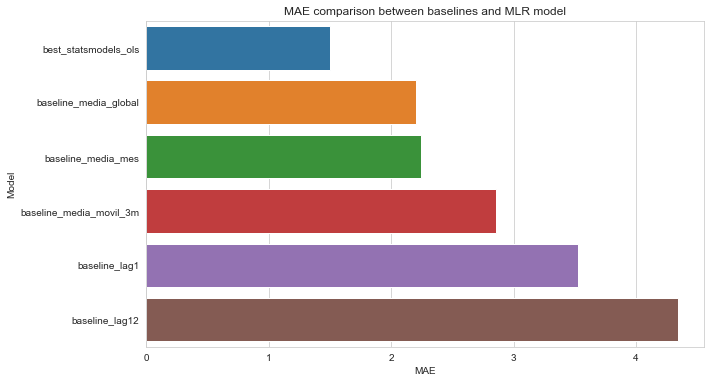

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_results,
    x='MAE',
    y='model'
)

plt.title('MAE comparison between baselines and MLR model')
plt.xlabel('MAE')
plt.ylabel('Model')

plt.show()

## RMSE comparison chart

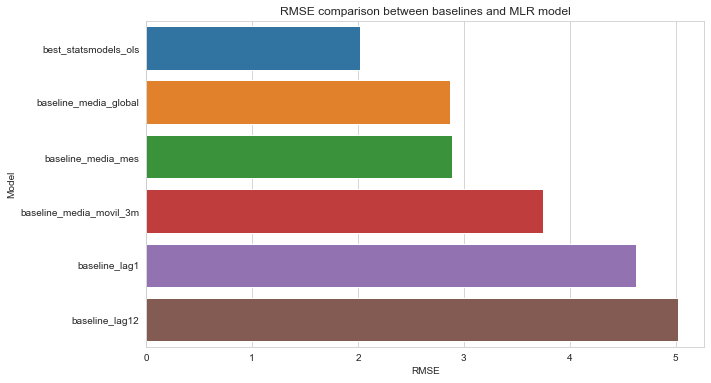

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_results.sort_values('RMSE'),
    x='RMSE',
    y='model'
)

plt.title('RMSE comparison between baselines and MLR model')
plt.xlabel('RMSE')
plt.ylabel('Model')

plt.show()

## MLR model prediction vs actual values

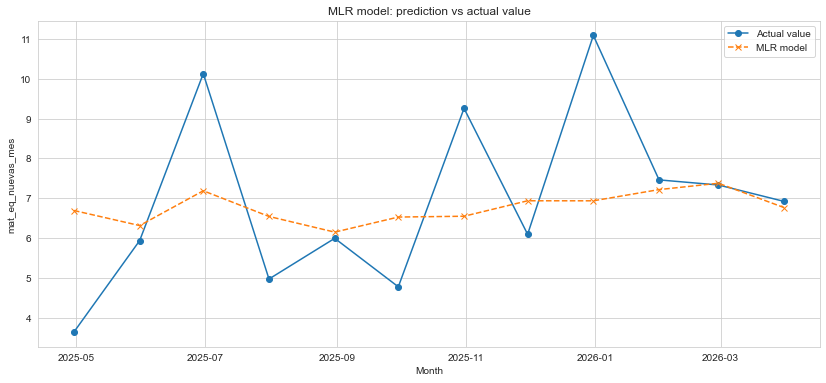

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_results['MES'].to_numpy(),
    test_results[target].to_numpy(),
    marker='o',
    label='Actual value'
)

plt.plot(
    test_results['MES'].to_numpy(),
    test_results['pred_rlm'].to_numpy(),
    marker='x',
    linestyle='--',
    label='MLR model'
)

plt.title('MLR model: prediction vs actual value')
plt.xlabel('Month')
plt.ylabel(target)
plt.legend()

plt.show()

## Visual comparison with the main baselines

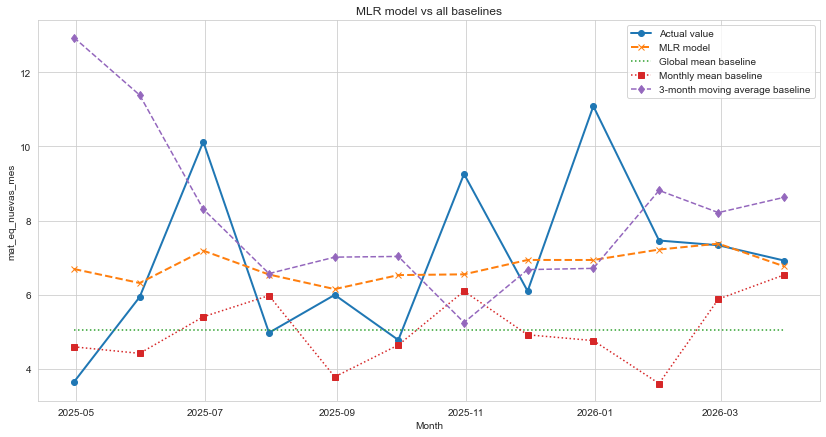

In [16]:
plt.figure(figsize=(14, 7))

plt.plot(
    test_results['MES'].to_numpy(),
    test_results[target].to_numpy(),
    marker='o',
    linewidth=2,
    label='Actual value'
)

plt.plot(
    test_results['MES'].to_numpy(),
    test_results['pred_rlm'].to_numpy(),
    marker='x',
    linestyle='--',
    linewidth=2,
    label='MLR model'
)

plt.plot(
    test_results['MES'].to_numpy(),
    test_results['pred_baseline_media_global'].to_numpy(),
    linestyle=':',
    label='Global mean baseline'
)

plt.plot(
    test_results['MES'].to_numpy(),
    test_results['pred_baseline_media_mes'].to_numpy(),
    linestyle=':',
    marker='s',
    label='Monthly mean baseline'
)

plt.plot(
    test_results['MES'].to_numpy(),
    test_results['pred_baseline_media_movil_3m'].to_numpy(),
    linestyle='--',
    marker='d',
    label='3-month moving average baseline'
)

plt.title('MLR model vs all baselines')
plt.xlabel('Month')
plt.ylabel(target)
plt.legend(loc='best')

plt.show()

# Part 3 — Evaluation of improvement over baselines

We calculate how much the MLR model improves or worsens compared with each baseline in terms of MAE.

In [17]:
rlm_model_name = 'best_statsmodels_ols'

rlm_mae = comparison_results.loc[
    comparison_results['model'] == rlm_model_name,
    'MAE'
].iloc[0]

improvement_rows = []

for _, row in comparison_results.iterrows():
    if row['model'] != rlm_model_name:
        baseline_mae = row['MAE']
        improvement_pct = (baseline_mae - rlm_mae) / baseline_mae * 100

        improvement_rows.append({
            'baseline': row['model'],
            'baseline_MAE': baseline_mae,
            'rlm_MAE': rlm_mae,
            'improvement_pct_vs_baseline': improvement_pct
        })

improvement_df = pd.DataFrame(improvement_rows).sort_values(
    'improvement_pct_vs_baseline',
    ascending=False
)

improvement_df

,baseline,baseline_MAE,rlm_MAE,improvement_pct_vs_baseline
4,baseline_lag12,4.3420,1.4976,65.5084
3,baseline_lag1,3.5286,1.4976,57.5573
2,baseline_media_movil_3m,2.8592,1.4976,47.6215
1,baseline_media_mes,2.2408,1.4976,33.1663
0,baseline_media_global,2.2040,1.4976,32.0488


## Automatic indicative decision

In [18]:
rlm_model_name = 'best_statsmodels_ols'

best_baseline_mae = comparison_results[
    comparison_results['model'] != rlm_model_name
]['MAE'].min()

best_baseline_name = comparison_results[
    comparison_results['model'] != rlm_model_name
].sort_values('MAE').iloc[0]['model']

rlm_rank = comparison_results[
    comparison_results['model'] == rlm_model_name
].index[0] + 1

improvement_vs_best_baseline = (best_baseline_mae - rlm_mae) / best_baseline_mae * 100

print('Best baseline:', best_baseline_name)
print('Best baseline MAE:', round(best_baseline_mae, 4))
print('MLR MAE:', round(rlm_mae, 4))
print('MLR model ranking:', rlm_rank, 'of', len(comparison_results))
print('MLR improvement over the best baseline:', round(improvement_vs_best_baseline, 2), '%')

if improvement_vs_best_baseline > 10:
    decision = 'The MLR model clearly improves upon the best baseline.'
elif improvement_vs_best_baseline > 0:
    decision = 'The MLR model improves upon the best baseline, although the improvement is moderate.'
else:
    decision = 'The MLR model does not improve upon the best baseline.'

print(decision)

Best baseline: baseline_media_global
Best baseline MAE: 2.204
MLR MAE: 1.4976
MLR model ranking: 1 of 6
MLR improvement over the best baseline: 32.05 %
The MLR model clearly improves upon the best baseline.


# Part 4 — Export results

The following outputs are saved:

- model comparison table,
- improvement table versus baselines,
- predictions from the MLR model and baselines on the test set,
- OLS model coefficients,
- summary information about the selected model.

In [19]:
os.makedirs('../outputs/reports', exist_ok=True)
os.makedirs('../outputs/model', exist_ok=True)

comparison_results.to_csv(
    '../outputs/reports/baselines_vs_rlm_comparison.csv',
    index=False
)

improvement_df.to_csv(
    '../outputs/reports/rlm_improvement_vs_baselines.csv',
    index=False
)

test_output_cols = [
    'MES',
    target,
    'pred_rlm',
    'pred_baseline_media_global',
    'pred_baseline_media_mes',
    'pred_baseline_lag1',
    'pred_baseline_lag12',
    'pred_baseline_media_movil_3m'
]

test_results[test_output_cols].to_csv(
    '../outputs/reports/test_predictions_baselines_vs_rlm.csv',
    index=False
)

coef_df.to_csv(
    '../outputs/reports/best_statsmodels_ols_coefficients.csv',
    index=False
)

best_model_info = pd.DataFrame([{
    'model_type': 'statsmodels_ols',
    'features': ' + '.join(BEST_FEATURES),
    'MAE_test': rlm_metrics['MAE'],
    'RMSE_test': rlm_metrics['RMSE'],
    'R2_test': rlm_metrics['R2'],
    'sMAPE_test': rlm_metrics['sMAPE'],
    'AIC_train': best_model.aic,
    'BIC_train': best_model.bic,
    'adj_R2_train': best_model.rsquared_adj
}])

best_model_info.to_csv(
    '../outputs/reports/best_statsmodels_ols_model_info.csv',
    index=False
)

print('OLS model results exported successfully.')

OLS model results exported successfully.


# Conclusions of Notebook 3

This notebook helps decide whether the `statsmodels_ols` model is worth using compared with simple prediction rules.

## How to interpret the results

The MLR model will be especially useful if it meets these conditions:

1. It has a lower MAE than the main baselines.
2. It clearly improves upon the historical monthly-mean baseline.
3. It improves upon or competes reasonably with the 3-month moving average.
4. It maintains a clear interpretation of the coefficients.
5. It does not depend on an excessive number of variables.

## Operational reading

If the OLS model improves upon the baselines, it can be used as a support tool to anticipate monthly equivalent new maternity leaves.

If the improvement is small, the model may still be useful as an explanatory framework, but it would be worth assessing whether a simple rule is sufficient for operational use.

If it does not improve upon the baselines, that conclusion is also valuable: it would indicate that, with the available information, multiple linear regression does not provide enough predictive advantage over simple methods.

## Next steps

Depending on the results, possible improvements include:

- testing rolling-origin validation,
- comparing with Ridge or Lasso,
- improving early-warning variables related to pregnancy-risk leave,
- adding prediction intervals,
- modeling the carry-over effect of active maternity leaves,
- incorporating the final model into the Streamlit application.

The final question is not whether the model is perfect, but whether it reduces uncertainty enough to support planning.

## Final conclusion

The comparison between the OLS multiple linear regression model and the simple baselines makes it possible to assess whether the model built **provides real predictive value**.

If the OLS model reduces MAE compared with the best baseline, it can be considered a first valid tool to support monthly equivalent new maternity leave forecasting. In that case, the model meets the minimum conditions defined for usefulness:

- it improves upon simple baselines;
- it maintains a reasonable operational mean error;
- it uses an interpretable structure;
- it anticipates the target variable better than naive rules.

The model does not eliminate uncertainty, but it can reduce it in a measurable way. The final decision should be based on the comparison table generated in this notebook and, especially, on the MAE improvement over the best baseline.